In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random, jit, vmap
from dataclasses import dataclass
from typing import Any
import matplotlib.pyplot as plt
import mcfile as mcf
import pickle
from scipy.spatial.distance import cdist

In [2]:
# ─── Primitives ───────────────────────────────────────────────────────────────
@jit
def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

@jit
def free_energy(W, bv, bh, v):
    """F(v; θ) per sample. Shape: (batch,)"""
    visible_term = jnp.dot(v, bv)
    hidden_input = jnp.dot(v, W.T) + bh
    # jnp.logaddexp(0, x) is the stable equivalent of log(1 + exp(x))
    hidden_term  = jnp.logaddexp(0, hidden_input).sum(axis=1)
    return -visible_term - hidden_term

@jit
def hidden_probs(W, bh, v):
    return sigmoid(jnp.dot(v, W.T) + bh)

@jit
def visible_probs(W, bv, h):
    return sigmoid(jnp.dot(h, W) + bv)

@jit
def sample(probs, key):
    return (random.uniform(key, shape=probs.shape) < probs).astype(jnp.float32)

# ─── Pseudo-Likelihood ────────────────────────────────────────────────────────

@jit
def pseudo_likelihood(W, bv, bh, v):
    """Computes the log pseudo-likelihood log PL(v) for a batch of visible vectors.
    
    PL(v) = \prod_{i} P(v_i | v_{-i})
    We use the efficient formula: P(v_i=1 | v_{-i}) = sigmoid(bv_i + \sum_j W_{ji} * hidden_activation)
    """
    # 1. Compute the effective input to the hidden layer from the visible state
    hidden_input = jnp.dot(v, W.T) + bh  # Shape: (batch, n_hidden)
    
    # 2. For each visible unit i, compute the log P(v_i | v_{-i})
    # We can vectorize this over all visible units i using matrix operations.
    # The term (v @ W.T) contains the contribution of all bits. To isolate v_{-i}, 
    # we can compute how the hidden activation changes when flipping the i-th bit.
    
    # To avoid explicit looping, we exploit the RBM structure: 
    # F(v with v_i=1) - F(v with v_i=0) = -bv_i - \sum_j log(1 + exp(W_ji + input_without_i))
    # Alternatively, an exact conditional distribution for bit i is:
    # P(v_i = 1 | v_{-i}) = sigmoid( bv_i + \sum_j log [ (1 + exp(W_ji + x_j - W_ji v_i)) / (1 + exp(x_j - W_ji v_i)) ] )
    
    # A standard fast approximation/exact trick for binary RBMs:
    # Compute free energy of original v, and free energy of v with bit i flipped.
    # Let's use vmap over the visible dimension to compute the flipped states quickly.
    n_visible = W.shape[1]
    batch_size = v.shape[0]
    
    def pl_for_unit(i):
        # Flip the i-th bit of the entire batch
        mask = jnp.zeros((n_visible,), dtype=jnp.float32).at[i].set(1.0)
        v_flipped = v + (1.0 - 2.0 * v) * mask  # flips 0->1 and 1->0
        
        fe_orig = free_energy(W, bv, bh, v)
        fe_flipped = free_energy(W, bv, bh, v_flipped)
        
        # P(v_i | v_{-i}) = exp(-F(v)) / (exp(-F(v)) + exp(-F(v_flipped)))
        #                 = 1 / (1 + exp(F(v) - F(v_flipped)))
        #                 = sigmoid(F(v_flipped) - F(v))
        # However, we only want the probability of the *observed* value of v_i.
        # If observed v_i == v_flipped_i (not possible), but conceptually:
        # log P(v_i) = - log(1 + exp(F(orig) - F(flipped))) if orig matches target.
        # Clean formulation: log P(v_i | v_{-i}) = -logaddexp(0, fe_orig - fe_flipped)
        return -jnp.logaddexp(0, fe_orig - fe_flipped)

    # vmap over the visible unit indices (axis 0 of the output)
    log_p_vi = vmap(pl_for_unit)(jnp.arange(n_visible)) # Shape: (n_visible, batch)
    
    # Sum across all visible units to get log PL for each sample, then mean over batch
    return log_p_vi.sum(axis=0)

# ─── Initialisation ───────────────────────────────────────────────────────────

def init_rbm(n_visible, n_hidden, key):
    k1, k2 = random.split(key)
    scale = jnp.sqrt(2 / (n_visible + n_hidden))
    W  = random.normal(k1, (n_hidden, n_visible)).astype(jnp.float32) * scale
    bv = jnp.zeros(n_visible, dtype=jnp.float32)
    bh = jnp.zeros(n_hidden,  dtype=jnp.float32)
    
    # Return k2 as the "new" key for the caller to use next
    return W, bv, bh, k2

def init_chains(n_chains, n_visible, key):
    k1, k2 = random.split(key)
    chains = random.randint(k1, (n_chains, n_visible), 0, 2).astype(jnp.float32)
    return chains, k2

# ─── PCD step ─────────────────────────────────────────────────────────────────

@jit
def pcd_step(W, bv, bh, v0, chains, lr, weight_decay, key):
    k1, k2 = random.split(key)

    # Positive phase
    ph0 = hidden_probs(W, bh, v0)

    # Negative phase — one Gibbs step on persistent chains
    ph_chain = hidden_probs(W, bh, chains)
    h_chain  = sample(ph_chain, k1)
    pv_chain = visible_probs(W, bv, h_chain)
    chains   = sample(pv_chain, k2)
    ph_neg   = hidden_probs(W, bh, chains)

    # Gradients
    dW  = (jnp.dot(ph0.T, v0) - jnp.dot(ph_neg.T, chains)) / len(v0)
    dbv = (v0 - chains).mean(axis=0)
    dbh = (ph0 - ph_neg).mean(axis=0)

    # Updates with L2 weight decay
    W  = W  + lr * dW  - weight_decay * W
    bv = bv + lr * dbv
    bh = bh + lr * dbh

    return W, bv, bh, chains

ewma_train = {"pl": None,
              "recon": None,    
              "fe": None,
              "cd": None}

ewma_val = {"pl": None,
            "recon": None,
            "fe": None,
            "cd": None}

@jit
def compute_metrics_batch(W, bv, bh, v0, key):
    """Processes a single batch for metrics to avoid memory bottlenecks."""
    k1, k2 = random.split(key)
    
    fe0 = free_energy(W, bv, bh, v0)
    log_pl = pseudo_likelihood(W, bv, bh, v0)

    # One Gibbs step → v1
    ph1 = hidden_probs(W, bh, v0)
    h1  = sample(ph1, k1)
    pv1 = visible_probs(W, bv, h1)
    v1  = sample(pv1, k2)

    fe1 = free_energy(W, bv, bh, v1)
    cd_loss = (fe0 - fe1).mean()
    recon_err = jnp.mean((v0 - v1) ** 2)
    
    return {"pl": log_pl.mean(),
            "fe":  fe0.mean(),
            "cd": cd_loss,
            "recon": recon_err}

def ewma_update(current, new, alpha):
    if current is None:
        return float(new)
    return (1.0 - alpha) * current + alpha * float(new)


def update_ewma(ewma_dict, metrics, alpha):
    for k, v in metrics.items():
        ewma_dict[k] = ewma_update(ewma_dict[k], v, alpha)


def make_header(metric_keys, width=12):
    s = f"{'epoch':>6}  "
    for k in metric_keys:
        s += f"{(k+'_tr'):>{width}}"
        s += f"{(k+'_val'):>{width}}  "
    return s


def print_metrics(epoch, train_metrics, val_metrics,
                  metric_keys=("pl", "recon", "fe", "cd"),
                  width=12):

    s = f"{epoch:>6}  "

    for k in metric_keys:
        s += f"{train_metrics[k]:>{width}.4f}"
        s += f"{val_metrics[k]:>{width}.4f}  "

    print(s)

def train(W, bv, bh, 
          train_data, test_data, epochs=500,
          batch_size=32, lr=0.005, weight_decay=1e-4,
          monitor_every=10, alpha=0.1, key=None):

    if key is None:
        raise ValueError("JAX requires an explicit random key.")

    metric_keys = ("pl", "recon", "fe", "cd")

    ewma_train = {k: None for k in metric_keys}
    ewma_val   = {k: None for k in metric_keys}

    history = []

    k_chain, k_loop = random.split(key)
    n_train = len(train_data)

    chains, k_chain = init_chains(batch_size, W.shape[1], k_chain)

    header = make_header(metric_keys)
    print(header)
    print("─" * len(header))

    for epoch in range(1, epochs + 1):

        k_loop, k_perm, k_step = random.split(k_loop, 3)

        idx = random.permutation(k_perm, n_train)

        # --------------------------
        # Training
        # --------------------------

        for start in range(0, n_train, batch_size):

            batch_idx = idx[start:start + batch_size]

            if len(batch_idx) < batch_size:
                continue

            batch = jnp.array(train_data[batch_idx], dtype=jnp.float32)

            k_step, subkey = random.split(k_step)

            W, bv, bh, chains = pcd_step(W,bv,bh,batch,chains,lr=lr, 
                                         weight_decay=weight_decay,key=subkey)

            metrics = compute_metrics_batch(W, bv, bh, batch, subkey)

            update_ewma(ewma_train, metrics, alpha)

        # --------------------------
        # Validation
        # --------------------------

        k_loop, k_val = random.split(k_loop)

        val_metrics = compute_metrics_batch(W, bv, bh, test_data, k_val)

        update_ewma(ewma_val, val_metrics, alpha)

        history.append({"epoch": epoch, "train": ewma_train.copy(),"val": ewma_val.copy()})

        if epoch == 1 or epoch % monitor_every == 0:
            print_metrics(epoch, ewma_train, ewma_val, metric_keys)

    return W, bv, bh, history

In [3]:
def bernoullise(spin_data):
    ''' convert  pm1 to 1,0 respectively'''
    spin_data = (spin_data > 0.0).astype(np.float32)
    return spin_data

def train_test_split(raw_data,train_frac=0.8, to_bernoullise=True):
    if to_bernoullise:
        raw_data= bernoullise(raw_data)
    shuffled_indices = np.random.permutation(len(raw_data))
    split_idx = int(train_frac * len(raw_data))
    train_data = raw_data[shuffled_indices[:split_idx]]
    test_data = raw_data[shuffled_indices[split_idx:]]
    
    return train_data, test_data

def reshape_and_truncate(data, remove_before = 7000):
    '''remove burn in'''
    data = data.reshape(len(data), -1)
    data = data[remove_before:]
    return data


def analyze_physical_hamiltonian(W, filename, grid_shape=None):
    """
    Visualizes the physical Hamiltonian coupling matrix (W^T * W) 
    and plots its interaction strengths as a function of real 2D spatial distance.
    
    Parameters:
        W: jnp.array or np.array, the weight matrix of shape (n_hidden, n_visible)
        grid_shape: tuple (height, width), spatial dimensions of your visible layer.
                    If None, assumes a square grid based on n_visible.
    """
    # 1. Convert JAX array to standard NumPy for plotting
    W_np = np.array(W)
    n_hidden, n_visible = W_np.shape
    
    if grid_shape is None:
        side = int(np.sqrt(n_visible))
        grid_shape = (side, side)
        assert grid_shape[0] * grid_shape[1] == n_visible, \
            f"Visible dimension {n_visible} is not a perfect square. Please specify grid_shape."

    # 2. Compute the physical Hamiltonian coupling matrix (W^T * W)
    # This represents the effective quadratic interactions between pixels
    J_physical = np.dot(W_np.T, W_np)
    np.fill_diagonal(J_physical, 0)  # Zero out self-interactions to isolate couplings

    # 3. Map visible units to actual 2D spatial coordinates
    x = np.arange(grid_shape[1])
    y = np.arange(grid_shape[0])
    X, Y = np.meshgrid(x, y)
    coordinates = np.vstack([Y.ravel(), X.ravel()]).T  # Shape: (n_visible, 2)

    # 4. Compute all pairwise 2D Euclidean distances between units
    distances = cdist(coordinates, coordinates, metric='euclidean')

    # Flatten both matrices to 1D arrays of length (n_visible * n_visible)
    flat_distances = distances.ravel()
    flat_couplings = J_physical.ravel()

    # ─── Plotting ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
    
    # Plot 1: The full Physical Hamiltonian Matrix
    im1 = axes[0].imshow(J_physical, cmap='bwr', aspect='equal')
    #axes[0].set_title(f"Physical Hamiltonian ($W^TW$)\nShape: {J_physical.shape}")
    axes[0].set_xlabel("Visible Unit Index")
    axes[0].set_ylabel("Visible Unit Index")
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Plot 2: Coupling Strength vs 2D Distance Histogram
    counts, xedges, yedges, im2 = axes[1].hist2d(flat_distances, 
                                                 flat_couplings, bins=200, 
                                                 cmap='viridis', cmin=1,alpha=0.7)
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    #axes[1].set_title("Interaction Strength vs. Spatial Distance")
    axes[1].set_xlabel("2D Spatial Distance (Pixels)")
    axes[1].set_ylabel("Coupling Value ($W^TW_{ij}$)")
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="Density Counts")
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def plot_metrics(history, filename, metric_keys=("pl", "recon", "fe", "cd")):
    """
    Plots training and validation EWMA metrics over epochs.
    
    Parameters
    ----------
    history : list of dicts
        Each dict has 'epoch', 'train', 'val' keys.
    metric_keys : tuple
        The metrics to plot.
    """
    epochs = [h["epoch"] for h in history]
    
    plt.figure(figsize=(12, 8))
    
    for i, k in enumerate(metric_keys, 1):
        plt.subplot(2, 2, i)
        
        train_vals = [h["train"][k] for h in history]
        val_vals   = [h["val"][k]   for h in history]
        
        plt.plot(epochs, train_vals, label="train", lw=2)
        plt.plot(epochs, val_vals,   label="val",   lw=2, ls="--")
        
        #plt.title(k)
        plt.xlabel("Epoch")
        plt.ylabel(k)
        plt.grid(True)
        if i == 1:
            plt.legend()
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

In [ ]:
b_c = 0.440687
sizes = [24,32,48,64]
L = sizes[0]

datadir = "ising_critical_scan_long"
data = mcf.build_dataframe(datadir)
bc_num = data['beta'][np.argmin(np.abs(np.array(data['beta'])-b_c))]


n_hidden = 16
batch_size = 64
epochs = 200
alpha = 0.15

In [ ]:
def bernoullise(spin_data):
    ''' convert  pm1 to 1,0 respectively'''
    spin_data = (spin_data > 0.0).astype(np.float32)
    return spin_data

def train_test_split(raw_data,train_frac=0.8, to_bernoullise=True):
    if to_bernoullise:
        raw_data= bernoullise(raw_data)
    shuffled_indices = np.random.permutation(len(raw_data))
    split_idx = int(train_frac * len(raw_data))
    train_data = raw_data[shuffled_indices[:split_idx]]
    test_data = raw_data[shuffled_indices[split_idx:]]
    
    return train_data, test_data

def reshape_and_truncate(data, remove_before = 7000):
    '''remove burn in'''
    data = data.reshape(len(data), -1)
    data = data[remove_before:]
    return data



In [ ]:
sector = 'PA'

snapshots = data.query('beta == @bc_num and sector == @sector and Lx == @L and Ly == @L')['spins']
snapshots = jnp.squeeze(jnp.array(np.stack(snapshots.to_numpy())))

snapshots = reshape_and_truncate(snapshots)
train_data, test_data = train_test_split(snapshots)

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    #rng  = jax.random.key(42)
    rng = random.PRNGKey(42)
    W, bv, bh, rng = init_rbm(train_data.shape[1], n_hidden=n_hidden, key=rng)
    W, bv, bh, history = train(W, bv, bh, train_data, test_data,
                               epochs=epochs, batch_size=batch_size, alpha=alpha, key=rng)

# Save (Serialize) data to a file
with open(f'{sector}rbmnh256.pkl', 'wb') as file:
    pickle.dump({'W': W, 'bv': bv, 'bh': bh, 'history': history}, file)

In [6]:
sector = 'AP'
snapshots = data.query('beta == @bc_num and sector == @sector and Lx == @L and Ly == @L')['spins']
snapshots = jnp.squeeze(jnp.array(np.stack(snapshots.to_numpy())))

snapshots = reshape_and_truncate(snapshots)
train_data, test_data = train_test_split(snapshots)

In [7]:

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    #rng  = jax.random.key(42)
    rng = random.PRNGKey(42)
    W, bv, bh, rng = init_rbm(train_data.shape[1], n_hidden=n_hidden, key=rng)
    W, bv, bh, history = train(W, bv, bh, train_data, test_data,
                               epochs=epochs, batch_size=batch_size, alpha=alpha, key=rng)

# Save (Serialize) data to a file
with open('aprbmnh256.pkl', 'wb') as file:
    pickle.dump({'W': W, 'bv': bv, 'bh': bh, 'history': history}, file)

 epoch         pl_tr      pl_val      recon_tr   recon_val         fe_tr      fe_val         cd_tr      cd_val  
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     1     -370.8091   -369.9023        0.4679      0.4659      -40.0549    -41.6674      -18.9526    -18.9670  
    10     -329.5304   -345.7496        0.3973      0.4251     -129.3275    -95.2731      -14.3949    -15.6380  
    20     -325.1814   -331.8656        0.3880      0.4000     -145.2447   -130.5510      -11.2007    -12.8932  


KeyboardInterrupt: 

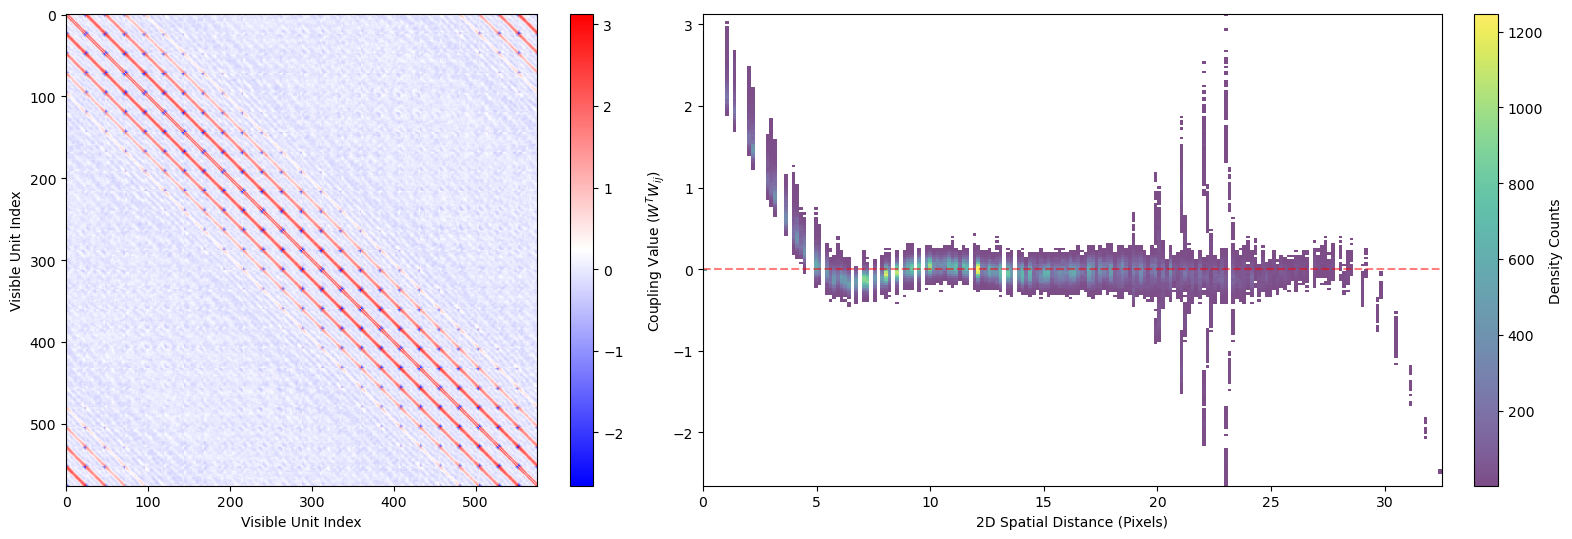

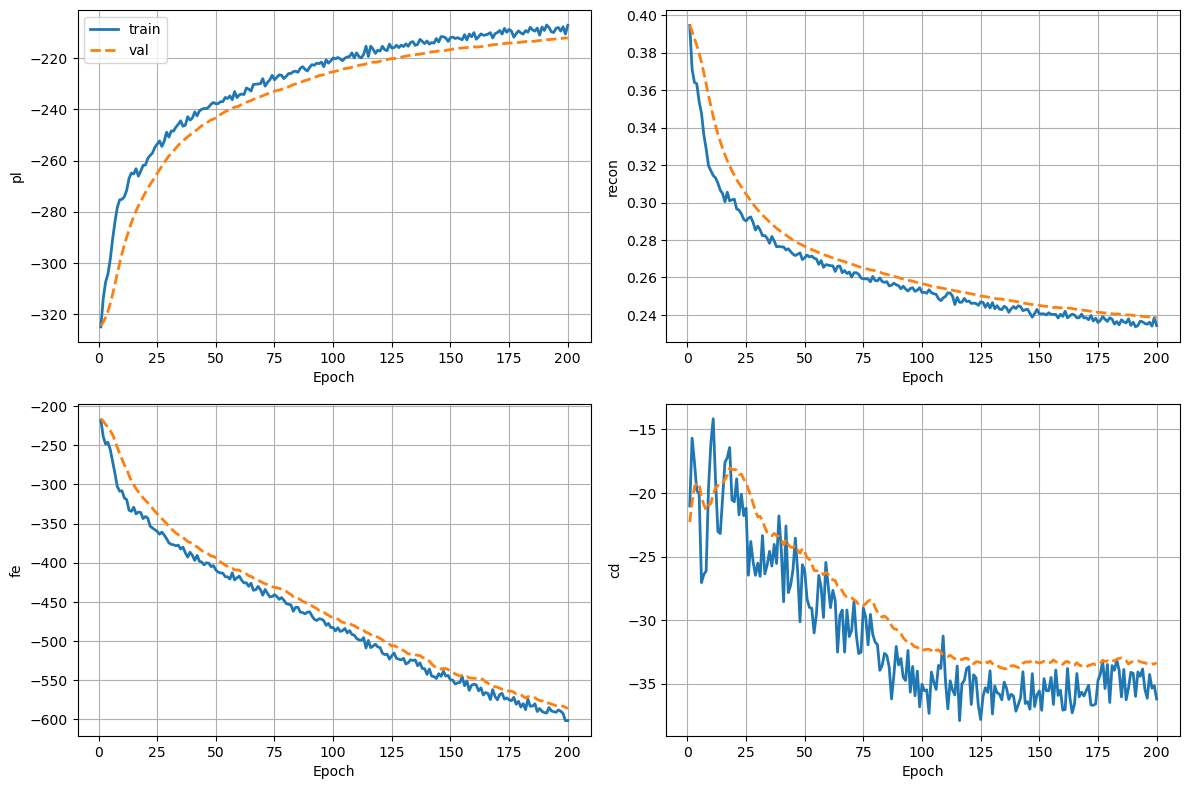

In [18]:
analyze_physical_hamiltonian(W,filename='rbmapW.pdf')
plot_metrics(history,filename='rbmaptraining.pdf')

In [19]:
sector = 'PA'

snapshots = data.query('beta == @bc_num and sector == @sector and Lx == @L and Ly == @L')['spins']
snapshots = jnp.squeeze(jnp.array(np.stack(snapshots.to_numpy())))

snapshots = reshape_and_truncate(snapshots)
train_data, test_data = train_test_split(snapshots)

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    #rng  = jax.random.key(42)
    rng = random.PRNGKey(42)
    W, bv, bh, rng = init_rbm(train_data.shape[1], n_hidden=n_hidden, key=rng)
    W, bv, bh, history = train(W, bv, bh, train_data, test_data,
                               epochs=epochs, batch_size=batch_size, alpha=alpha, key=rng)

# Save (Serialize) data to a file
with open(f'{sector}rbmnh256.pkl', 'wb') as file:
    pickle.dump({'W': W, 'bv': bv, 'bh': bh, 'history': history}, file)

 epoch         pl_tr      pl_val      recon_tr   recon_val         fe_tr      fe_val         cd_tr      cd_val  
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     1     -325.0542   -325.8636        0.3964      0.3946     -223.7409   -219.0775      -22.9655    -20.7380  
    10     -273.3623   -297.0327        0.3169      0.3525     -322.1862   -278.6804      -20.6221    -21.1992  
    20     -259.7789   -273.3252        0.2974      0.3162     -353.9324   -328.0366      -19.3783    -18.9587  
    30     -251.2264   -259.2726        0.2884      0.2983     -378.3453   -360.8686      -25.2334    -22.8507  
    40     -244.1705   -250.6381        0.2788      0.2868     -395.6557   -380.6680      -24.6742    -24.4108  
    50     -236.6809   -244.4027        0.2711      0.2791     -413.7405   -399.2275      -28.7560    -26.0590  
    60     -235.1154   -239.6622        0.2678      0.2733     -420.6756   -413.9613      -27.45

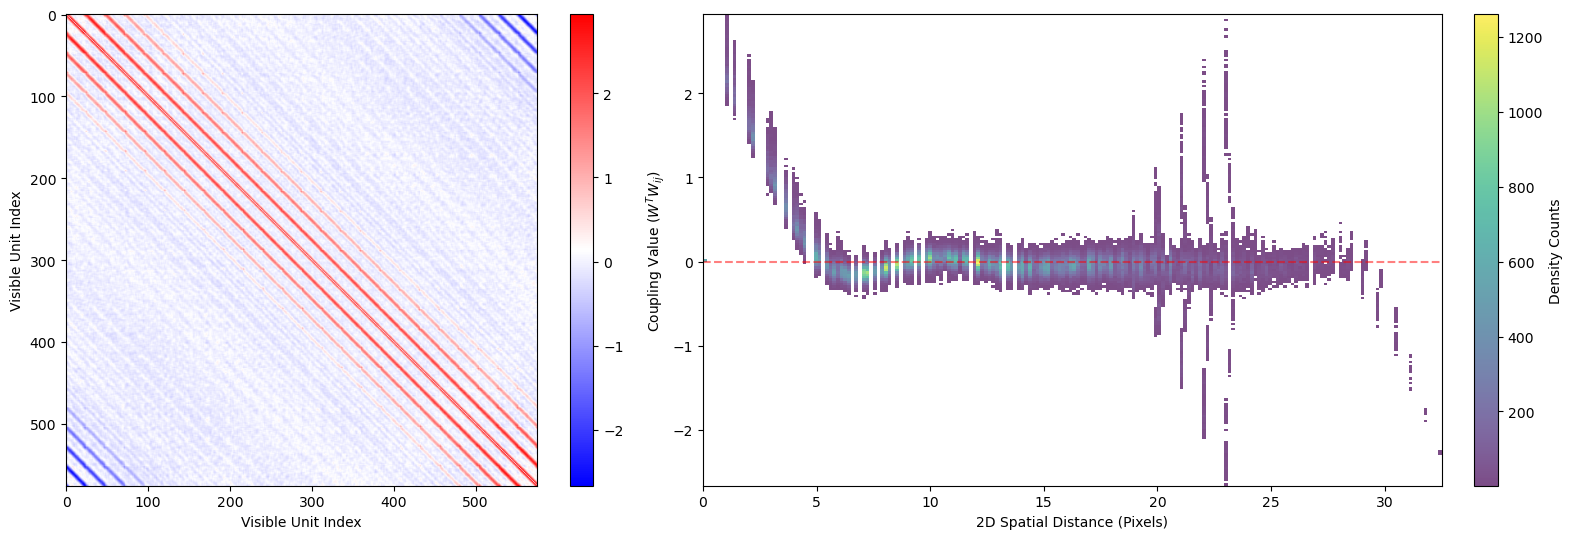

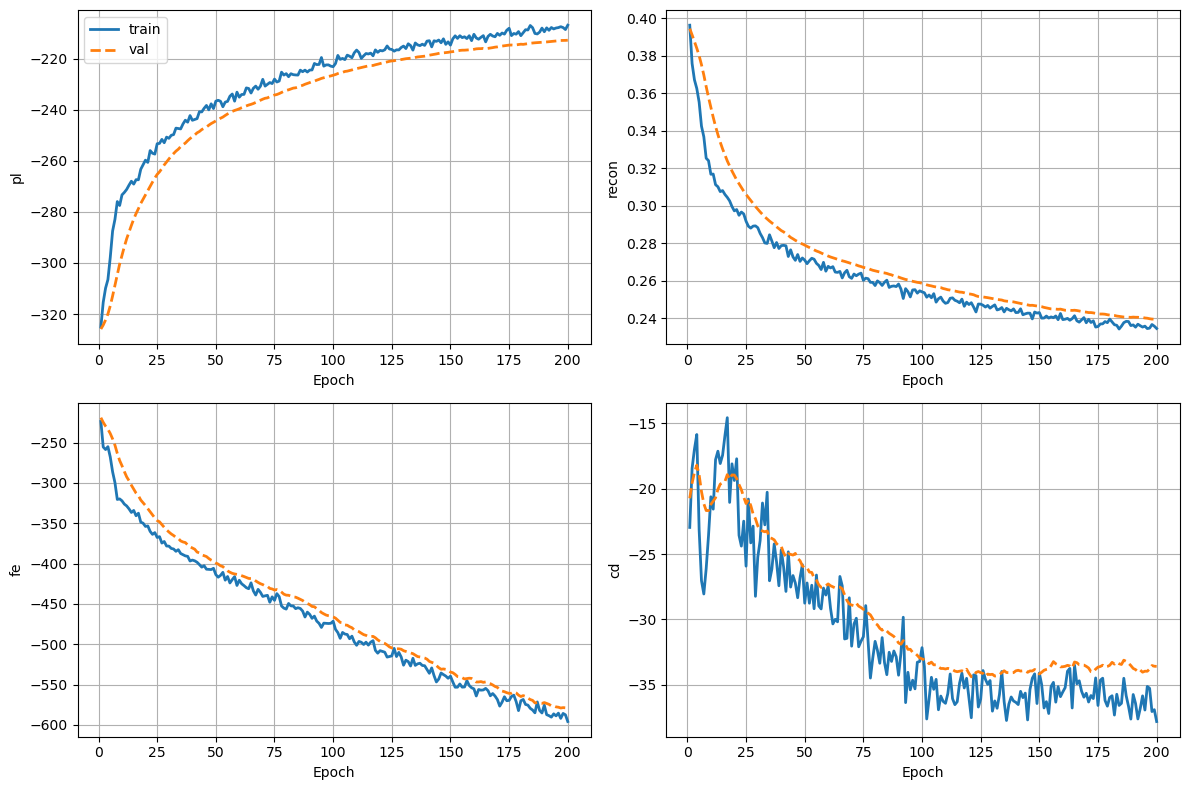

In [20]:
analyze_physical_hamiltonian(W,filename='rbmpaW.pdf')
plot_metrics(history,filename='rbmpatraining.pdf')

In [21]:
sector = 'AA'
snapshots = data.query('beta == @bc_num and sector == @sector and Lx == @L and Ly == @L')['spins']
snapshots = jnp.squeeze(jnp.array(np.stack(snapshots.to_numpy())))

snapshots = reshape_and_truncate(snapshots)
train_data, test_data = train_test_split(snapshots)

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    #rng  = jax.random.key(42)
    rng = random.PRNGKey(42)
    W, bv, bh, rng = init_rbm(train_data.shape[1], n_hidden=n_hidden, key=rng)
    W, bv, bh, history = train(W, bv, bh, train_data, test_data,
                               epochs=epochs, batch_size=batch_size, alpha=alpha, key=rng)

# Save (Serialize) data to a file
with open(f'{sector}rbmnh256.pkl', 'wb') as file:
    pickle.dump({'W': W, 'bv': bv, 'bh': bh, 'history': history}, file)

 epoch         pl_tr      pl_val      recon_tr   recon_val         fe_tr      fe_val         cd_tr      cd_val  
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     1     -318.3063   -317.0101        0.3898      0.3868     -252.3547   -256.0078      -31.8988    -30.6044  
    10     -275.1622   -290.8546        0.3200      0.3412     -328.8802   -306.5045      -17.9249    -17.7566  
    20     -250.8199   -264.1513        0.2885      0.3066     -380.2601   -353.5449      -25.5015    -23.7279  
    30     -244.1461   -251.3504        0.2782      0.2877     -403.5399   -386.2514      -24.3255    -23.3080  
    40     -238.2326   -244.5527        0.2719      0.2784     -412.8193   -402.6836      -26.7061    -23.7537  
    50     -235.0841   -240.4773        0.2667      0.2726     -421.6181   -413.6179      -25.4597    -23.8351  
    60     -233.0176   -237.1723        0.2651      0.2683     -433.0863   -423.9147      -27.08

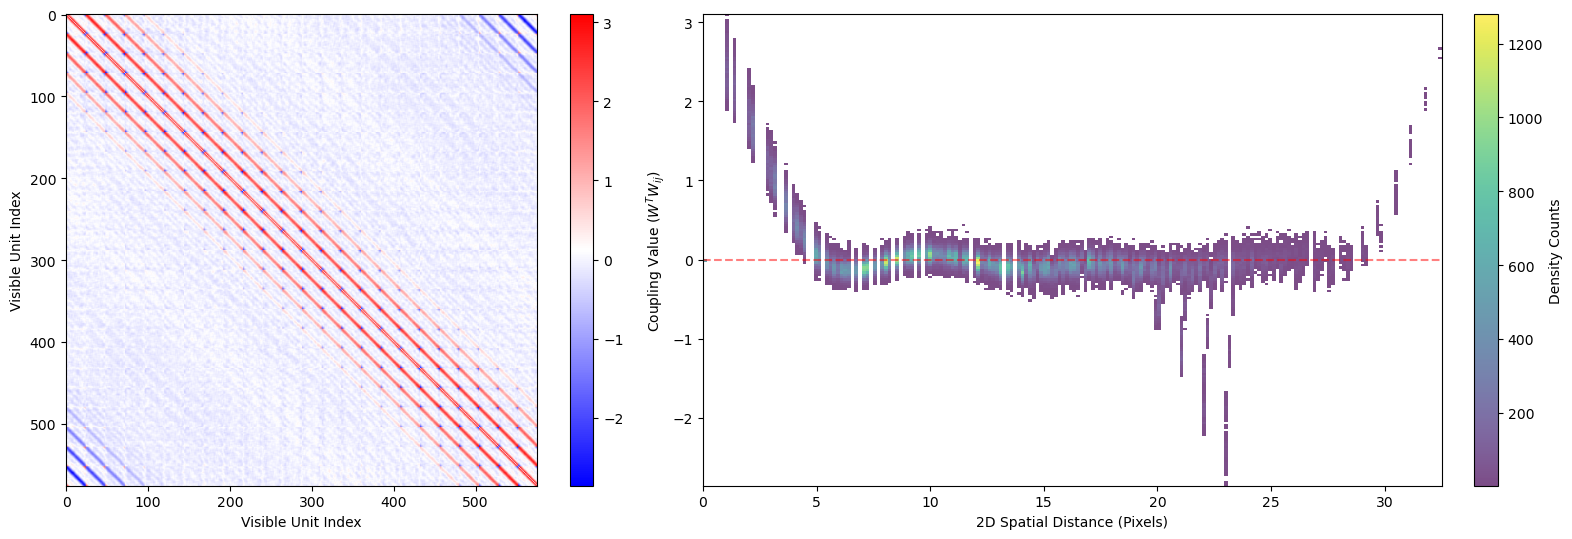

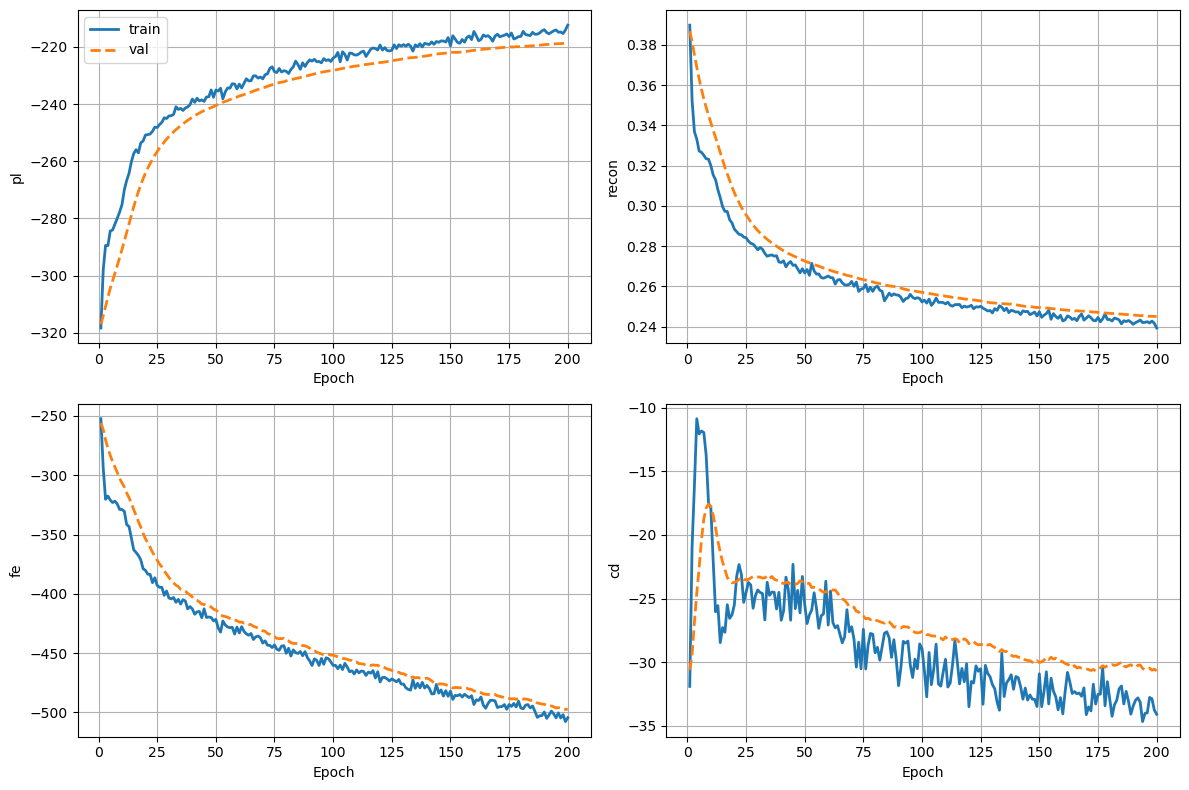

In [22]:
analyze_physical_hamiltonian(W,filename='rbmaaW.pdf')
plot_metrics(history,filename='rbmaatraining.pdf')

In [31]:
def physicalH(W, grid_shape=None):
    
    W_np = np.array(W)
    n_hidden, n_visible = W_np.shape
    
    if grid_shape is None:
        side = int(np.sqrt(n_visible))
        grid_shape = (side, side)
        assert grid_shape[0] * grid_shape[1] == n_visible, \
            f"Visible dimension {n_visible} is not a perfect square. Please specify grid_shape."

    # 2. Compute the physical Hamiltonian coupling matrix (W^T * W)
    # This represents the effective quadratic interactions between pixels
    J_physical = np.dot(W_np.T, W_np)
    np.fill_diagonal(J_physical, 0)  # Zero out self-interactions to isolate couplings
    return J_physical

h2set, HistSet = [], []
files = ['pprbmnh256.pkl','aprbmnh256.pkl','PArbmnh256.pkl','AArbmnh256.pkl']
for file in files:
    with open(file, 'rb') as handle:
        my_dict = pickle.load(handle)
        h2set.append(physicalH(my_dict['W']))
        HistSet.append(my_dict['history'])

filename = 'rbm_covariance.pdf'
fig, axes = plt.subplots(1, 4, figsize=(18, 5.5))
key = ['PP', 'AP','PA', 'AA']
for i, J_physical in enumerate(h2set):
    flat_couplings = J_physical.ravel()
    im = axes[i].imshow(J_physical, cmap='bwr', aspect='equal')
    axes[i].set_title(key[i])
    if i==0:
        axes[i].set_xlabel("Visible Unit Index")
        axes[i].set_ylabel("Visible Unit Index")
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(filename)
plt.show()

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_covariance_torus(H, Lx, Ly, ax = None, threshold_percentile=98, R=3.0, r=1.0):
    """
    Maps a periodic 2D lattice onto a 3D Torus and plots covariance links between sites.
    
    Parameters:
        data: np.array or jnp.array of shape (n_samples, n_visible)
        grid_shape: tuple (height, width). Assumed square if None.
        threshold_percentile: Top % of absolute covariance connections to draw.
        R: float, major radius of the torus (distance from center of tube to center of donut).
        r: float, minor radius of the torus (radius of the tube itself).
    """
    cov_matrix = H
    width = Lx
    height = Ly
    abs_cov = np.abs(H)
    
    threshold = np.percentile(abs_cov, threshold_percentile)

    # 2. Map 2D grid coordinates to 3D Torus parametric space
    # Theta wraps around the ring (width), Phi wraps around the tube (height)
    theta = np.linspace(0, 2 * np.pi, width, endpoint=False)
    phi = np.linspace(0, 2 * np.pi, height, endpoint=False)
    
    Theta, Phi = np.meshgrid(theta, phi)
    Theta = Theta.ravel()
    Phi = Phi.ravel()

    # Parametric equations for a torus
    X = (R + r * np.cos(Phi)) * np.cos(Theta)
    Y = (R + r * np.cos(Phi)) * np.sin(Theta)
    Z = r * np.sin(Phi)
    
    coords_3d = np.vstack([X, Y, Z]).T # Shape: (n_visible, 3)

    if ax is None:
        # 3. Setup 3D Plot if not already specified into a subplot
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

    # Plot the lattice nodes on the surface of the torus
    ax.scatter(coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2], 
               color='lightgray', s=20, alpha=0.8, edgecolors='gray', zorder=5)

    # 4. Filter and draw the links
    ii, jj = np.where(abs_cov > threshold)
    seen_edges = set()
    max_val = np.max(abs_cov)

    for i, j in zip(ii, jj):
        if (i, j) in seen_edges or (j, i) in seen_edges:
            continue
        seen_edges.add((i, j))

        val = cov_matrix[i, j]
        abs_val = abs_cov[i, j]
        
        edge_color = 'dodgerblue' if val > 0 else 'crimson'
        line_width = (abs_val / max_val) *0.5 if val >0 else 1 #* 3.0
        alpha_val = 0.2 + 0.8 * (abs_val / max_val)

        # Draw the 3D link bridging site i and site j across the surface
        ax.plot(
            [coords_3d[i, 0], coords_3d[j, 0]], 
            [coords_3d[i, 1], coords_3d[j, 1]], 
            [coords_3d[i, 2], coords_3d[j, 2]], 
            color=edge_color, 
            linewidth=line_width, 
            alpha=alpha_val,
            zorder=4
        )
    
    # Balance axes proportions so the donut doesn't stretch weirdly
    max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Z.max()-Z.min()]).max() / 2.0
    mid_x = (X.max()+X.min()) / 2.0
    mid_y = (Y.max()+Y.min()) / 2.0
    mid_z = (Z.max()+Z.min()) / 2.0
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    #ax.dist = 1
    #zoom = 0.75
    
    zoom = 0.6   # smaller -> bigger torus
    
    ax.set_xlim(mid_x - zoom * max_range,
                mid_x + zoom * max_range)
    ax.set_ylim(mid_y - zoom * max_range,
                mid_y + zoom * max_range)
    ax.set_zlim(mid_z - zoom * max_range,
                mid_z + zoom * max_range)
    ax.dist = 6
    ax.set_box_aspect([1,1,1])
    
    ax.axis('off')
    return ax
    #plt.show()

# Run it directly on your training data array:
# visualize_covariance_torus(train_data, grid_shape=(28, 28), threshold_percentile=99)

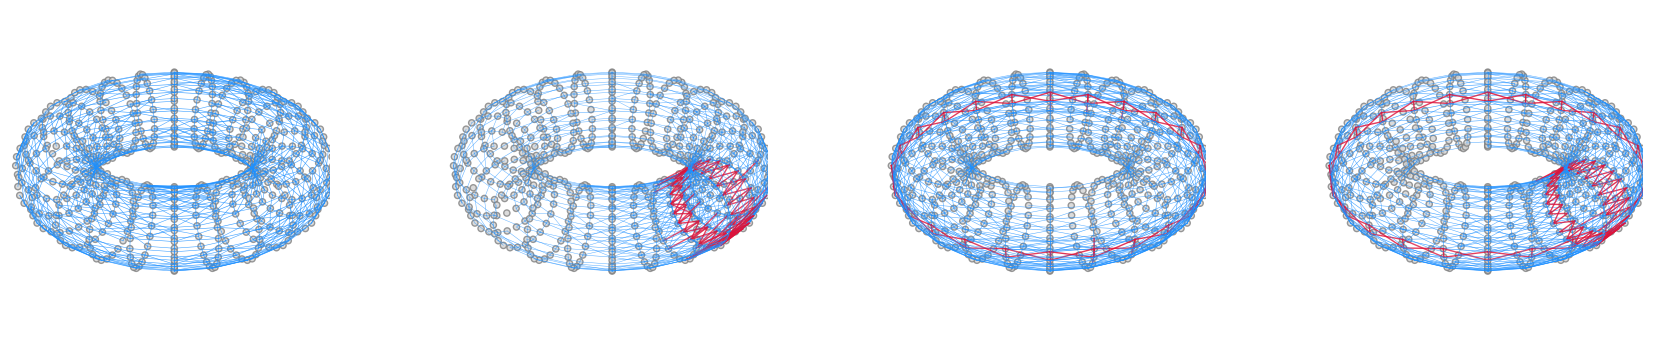

In [79]:
filename = 'rbm_covariance_torus.pdf'

key = ['PP', 'AP','PA', 'AA']
fig = plt.figure(figsize=(18, 3.5))

axes = []
for i in range(4):
    # Create a 3D subplot explicitly
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    axes.append(ax)

# Loop over your Hamiltonians / covariances
for i, J_physical in enumerate(h2set):
    axes[i] = visualize_covariance_torus(J_physical, Lx=24, Ly=24,
                               ax=axes[i],
                               threshold_percentile=99)
plt.tight_layout()
plt.savefig(filename)
plt.show()

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def plot_translational_invariance(W, grid_shape):
    """
    Computes and plots the average effective coupling map relative to 2D periodic displacement.
    """
    W_np = np.array(W)
    n_hidden, n_visible = W_np.shape
    h, w = grid_shape
    
    # Compute the physical Hamiltonian
    J = np.dot(W_np.T, W_np)
    np.fill_diagonal(J, 0)
    
    # Grid coordinates
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T  # (n_visible, 2)
    
    # Map accumulator for periodic displacements: dy in [-h//2, h//2], dx in [-w//2, w//2]
    accum = np.zeros((h, w))
    counts = np.zeros((h, w))
    
    # Loop over all pairs (or vectorized if memory permits)
    for i in range(n_visible):
        # Periodic relative displacements from site i to all sites
        dx = coords[:, 0] - coords[i, 0]
        dy = coords[:, 1] - coords[i, 1]
        
        # Apply periodic boundary conditions (minimum image convention)
        dx = (dx + w // 2) % w - w // 2
        dy = (dy + h // 2) % h - h // 2
        
        # Shift indices to [0, h-1] and [0, w-1] for matrix storage
        idx_x = dx + w // 2
        idx_y = dy + h // 2
        
        accum[idx_y, idx_x] += J[i, :]
        counts[idx_y, idx_x] += 1
        
    avg_coupling_map = accum / counts

    # Plot the centered interaction profile
    plt.figure(figsize=(7, 6))
    plt.imshow(avg_coupling_map, cmap='bwr', origin='lower',
               extent=[-w//2, w//2, -h//2, h//2])
    plt.colorbar(label='Average Effective Coupling Strength')
    plt.title("Translationally Averaged Coupling Map\n(Centered at 0 Displacement)")
    plt.xlabel(r"Periodic $\Delta x$")
    plt.ylabel(r"Periodic $\Delta y$")
    plt.show()

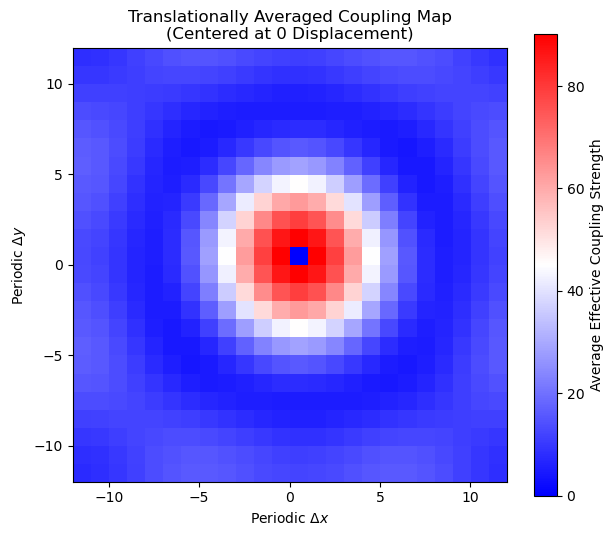

In [81]:
plot_translational_invariance(W = h2set[0], grid_shape = (24, 24))

In [114]:
from scipy.spatial.distance import cdist

def plot_scale_invariance_analysis(J, grid_shape):
    """
    Analyzes scale invariance by checking for power-law decay of couplings
    using a log-log spatial distance analysis.
    """
    # W_np = np.array(W)
    # n_hidden, n_visible = W_np.shape
    h, w = grid_shape
    
    # J = np.dot(W_np.T, W_np)
    # np.fill_diagonal(J, 0)
    #J = W
    # 2. Toroidal Distance Matrix Calculation
    # 2. Toroidal L1 (Manhattan) Distance Matrix Calculation
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    
    # Compute the periodic dx and dy arrays using the minimum image convention
    dx = cdist(coords[:, :1], coords[:, :1], lambda u, v: (u - v + w//2) % w - w//2)
    dy = cdist(coords[:, 1:], coords[:, 1:], lambda u, v: (u - v + h//2) % h - h//2)
    
    # FIX: Sum the absolute values for Toroidal L1 distance
    toroidal_distances = np.abs(dx) + np.abs(dy)
    
    flat_dists = toroidal_distances.ravel()
    flat_couplings = np.abs(J).ravel()
    
    # Isolate unique integer distances greater than 0
    unique_dists = np.unique(flat_dists)
    unique_dists = unique_dists[unique_dists > 0]
    
    mean_couplings = np.array([np.mean(flat_couplings[flat_dists == d]) for d in unique_dists])
    
    flat_dists = toroidal_distances.ravel()
    flat_couplings = np.abs(J).ravel()
    
    # Isolate unique distances greater than 0
    unique_dists = np.unique(flat_dists)
    unique_dists = unique_dists[unique_dists > 0]
    
    mean_couplings = np.array([np.mean(flat_couplings[flat_dists == d]) 
                               for d in unique_dists])
    
    # 3. Plotting in Log-Log Space
    plt.figure(figsize=(8, 5))
    #plt.loglog(unique_dists, mean_couplings, marker='o', linestyle='-', color='darkgreen', label='Model $W^TW$')
    
    # Fit a straight line in log-log space to find the power-law exponent
    # (Excluding the very edge tail where finite-size torus effects warp behavior)
    fit_mask = unique_dists < (min(h, w)/2)
    plt.loglog(unique_dists[fit_mask], mean_couplings[fit_mask], marker='o', linestyle='-', color='darkgreen', label='Model $W^TW$')
    if np.sum(fit_mask) > 1:
        slope, intercept = np.polyfit(np.log(unique_dists[fit_mask]), np.log(mean_couplings[fit_mask]), 1)
        # Generate theoretical power law line for visual reference
        plt.loglog(unique_dists[fit_mask], np.exp(intercept) * (unique_dists[fit_mask] ** slope), 
                   linestyle='--', color='orange', label=f'Power-law Fit ($\propto r^{{{slope:.2f}}}$)')
    
    plt.title("Coupling Decay in Log-Log Space (Scale Invariance Check)")
    plt.xlabel("Log Spatial Distance (Toroidal)")
    plt.ylabel("Log Mean Absolute Coupling |$W^TW$|")
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend()
    plt.show()

24


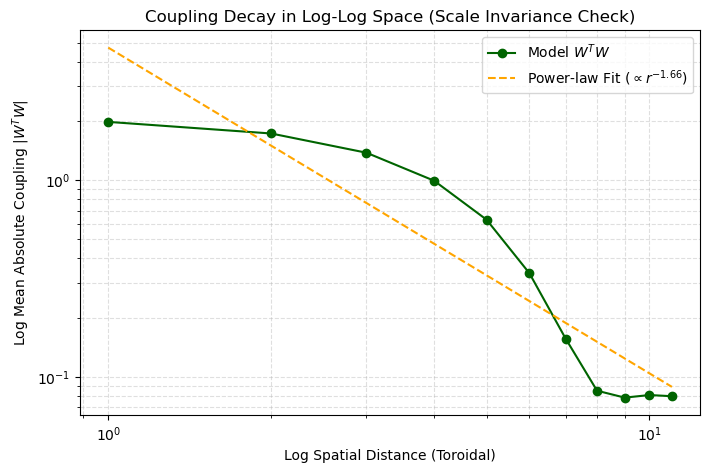

In [116]:
plot_scale_invariance_analysis(J = h2set[0], grid_shape = (24, 24))

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def plot_scale_invariance_analysis(J, grid_shape):
    """
    Analyzes scale invariance by checking for power-law decay of couplings
    using a log-log spatial distance analysis. Plots the statistical spread
    (Interquartile Range) to visualize variance across identical distances.
    """
    h, w = grid_shape
    
    # 1. Toroidal L1 (Manhattan) Distance Matrix Calculation
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    
    # Compute the periodic dx and dy arrays using the minimum image convention
    dx = cdist(coords[:, :1], coords[:, :1], lambda u, v: (u - v + w//2) % w - w//2)
    dy = cdist(coords[:, 1:], coords[:, 1:], lambda u, v: (u - v + h//2) % h - h//2)
    
    # Toroidal L1 distance
    toroidal_distances = np.abs(dx) + np.abs(dy)
    
    flat_dists = toroidal_distances.ravel()
    flat_couplings = np.abs(J).ravel()
    
    # Isolate unique integer distances greater than 0
    unique_dists = np.unique(flat_dists)
    unique_dists = unique_dists[unique_dists > 0]
    
    # 2. Compute Mean, Median, and Spread (25th and 75th percentiles)
    mean_couplings = []
    median_couplings = []
    p25_couplings = []
    p75_couplings = []
    
    for d in unique_dists:
        couplings_at_d = flat_couplings[flat_dists == d]
        
        mean_couplings.append(np.mean(couplings_at_d))
        median_couplings.append(np.median(couplings_at_d))
        p25_couplings.append(np.percentile(couplings_at_d, 25))
        p75_couplings.append(np.percentile(couplings_at_d, 75))
        
    mean_couplings = np.array(mean_couplings)
    median_couplings = np.array(median_couplings)
    p25_couplings = np.array(p25_couplings)
    p75_couplings = np.array(p75_couplings)
    
    # 3. Apply the Fit Mask (truncate before finite-size boundary artifacts kick in)
    fit_mask = unique_dists < (min(h, w) / 2)
    
    # 4. Plotting in Log-Log Space
    plt.figure(figsize=(9, 6))
    
    # Plot the statistical spread envelope (IQR)
    plt.fill_between(
        unique_dists[fit_mask], 
        p25_couplings[fit_mask], 
        p75_couplings[fit_mask], 
        color='darkgreen', 
        alpha=0.15, 
        label='Coupling Spread (25th - 75th Percentile)'
    )
    
    # Plot the central trend lines
    plt.loglog(unique_dists[fit_mask], median_couplings[fit_mask], 
               marker='s', linestyle=':', color='forestgreen', label='Median Coupling')
    plt.loglog(unique_dists[fit_mask], mean_couplings[fit_mask], 
               marker='o', linestyle='-', color='darkgreen', label='Mean Coupling')
    
    # Fit a straight line to the mean in log-log space to find the power-law exponent
    if np.sum(fit_mask) > 1:
        slope, intercept = np.polyfit(
            np.log(unique_dists[fit_mask]), 
            np.log(mean_couplings[fit_mask]), 1
        )
        # Generate theoretical power law line for visual reference
        plt.loglog(
            unique_dists[fit_mask], 
            np.exp(intercept) * (unique_dists[fit_mask] ** slope), 
            linestyle='--', 
            color='orange', 
            linewidth=2,
            label=f'Power-law Fit ($\propto r^{{{slope:.2f}}}$)'
        )
    
    plt.title("Coupling Decay & Variance in Log-Log Space", fontsize=13)
    plt.xlabel("Log Spatial Distance (Toroidal L1)")
    plt.ylabel("Log Absolute Coupling |$W^TW$|")
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import scipy.stats as stats

def plot_scale_invariance_analysis(J, grid_shape):
    """
    Analyzes scale invariance by checking for power-law decay of couplings.
    Plots the statistical spread of raw couplings and incorporates a 95% 
    confidence band for the fitted power-law regression line.
    """
    h, w = grid_shape
    
    # 1. Toroidal L1 (Manhattan) Distance Matrix Calculation
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    
    dx = cdist(coords[:, :1], coords[:, :1], lambda u, v: (u - v + w//2) % w - w//2)
    dy = cdist(coords[:, 1:], coords[:, 1:], lambda u, v: (u - v + h//2) % h - h//2)
    toroidal_distances = np.abs(dx) + np.abs(dy)
    
    flat_dists = toroidal_distances.ravel()
    flat_couplings = np.abs(J).ravel()
    
    unique_dists = np.unique(flat_dists)
    unique_dists = unique_dists[unique_dists > 0]
    
    # 2. Compute Mean, Median, and Spread
    mean_couplings = []
    median_couplings = []
    p25_couplings = []
    p75_couplings = []
    
    for d in unique_dists:
        couplings_at_d = flat_couplings[flat_dists == d]
        mean_couplings.append(np.mean(couplings_at_d))
        median_couplings.append(np.median(couplings_at_d))
        p25_couplings.append(np.percentile(couplings_at_d, 25))
        p75_couplings.append(np.percentile(couplings_at_d, 75))
        
    mean_couplings = np.array(mean_couplings)
    median_couplings = np.array(median_couplings)
    p25_couplings = np.array(p25_couplings)
    p75_couplings = np.array(p75_couplings)
    
    # 3. Apply the Fit Mask
    fit_mask = unique_dists < (min(h, w) / 2)
    x_fit = np.log(unique_dists[fit_mask])
    y_fit = np.log(mean_couplings[fit_mask])
    n_points = len(x_fit)
    
    # 4. Plotting Initialization
    plt.figure(figsize=(9, 6))
    
    # Plot raw data envelope
    plt.fill_between(
        unique_dists[fit_mask], p25_couplings[fit_mask], p75_couplings[fit_mask], 
        color='darkgreen', alpha=0.10, label='Data IQR (25th - 75th Percentile)'
    )
    plt.loglog(unique_dists[fit_mask], median_couplings[fit_mask], 
               marker='s', linestyle=':', color='forestgreen', label='Median Coupling')
    plt.loglog(unique_dists[fit_mask], mean_couplings[fit_mask], 
               marker='o', linestyle='-', color='darkgreen', label='Mean Coupling')
    
    # 5. Advanced Linear Regression with Confidence Intervals
    if n_points > 2:
        # Perform rigorous linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)
        
        # Calculate regression lines
        y_pred = intercept + slope * x_fit
        
        # Calculate standard error of the regression estimate (residuals)
        residuals = y_fit - y_pred
        s_err = np.sqrt(np.sum(residuals**2) / (n_points - 2))
        
        # Calculate 95% confidence interval boundaries for the line
        # t-value for two-tailed 95% confidence
        t_val = stats.t.ppf(0.975, df=n_points-2)
        
        x_mean = np.mean(x_fit)
        sum_sq_x = np.sum((x_fit - x_mean)**2)
        
        # Compute the specific standard error for each evaluated coordinate
        fit_se = s_err * np.sqrt(1.0/n_points + ((x_fit - x_mean)**2) / sum_sq_x)
        
        # Map boundaries out of log space back to original values
        lower_bound = np.exp(y_pred - t_val * fit_se)
        upper_bound = np.exp(y_pred + t_val * fit_se)
        fit_line = np.exp(y_pred)
        
        # Plot the Shaded Fit Confidence Band
        plt.fill_between(
            unique_dists[fit_mask], lower_bound, upper_bound, 
            color='orange', alpha=0.25, label='95% Fit Confidence Interval'
        )
        
        # Plot the primary Fit Line
        plt.loglog(
            unique_dists[fit_mask], fit_line, 
            linestyle='--', color='darkorange', linewidth=2,
            label=f'Power-law Fit ($\propto r^{{{slope:.2f} \pm {t_val*std_err:.2f}}}$)'
        )
    
    plt.xlabel("Log Spatial Distance (Toroidal L1)")
    plt.ylabel("Log Absolute Coupling |$W^TW$|")
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.savefig('rbm_scale_invariance.pdf')
    plt.show()

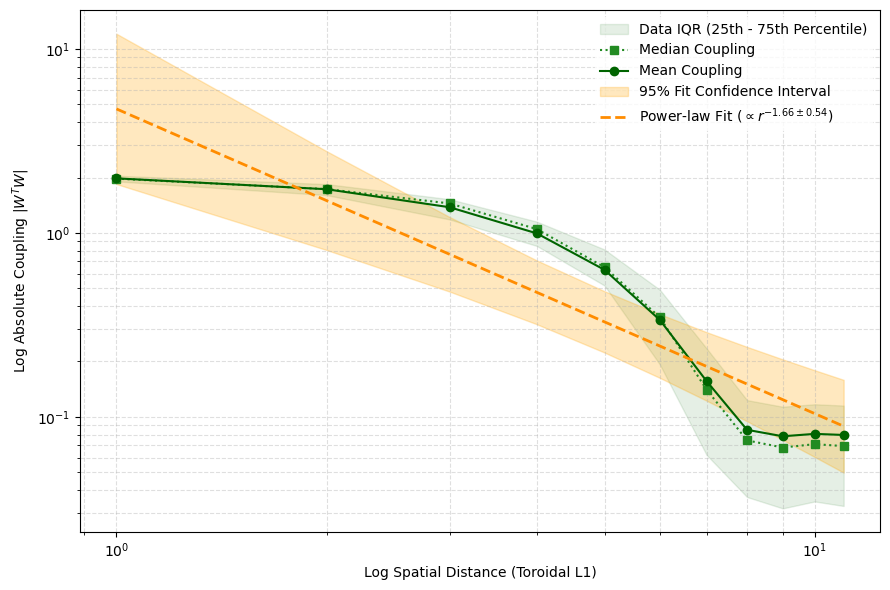

In [123]:
plot_scale_invariance_analysis(J = (h2set[0]+h2set[0])/2, grid_shape = (24, 24))

In [85]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metrics_combined(
    history,
    metric_keys=("pl", "recon", "fe", "cd"),
    normalize=None,  # None | "minmax" | "zscore"
):
    """
    Plot all training and validation metrics on a single figure.

    Parameters
    ----------
    history : list of dict
        Each element: {"epoch": int, "train": dict, "val": dict}
    metric_keys : iterable
        Metrics to plot.
    normalize : str or None
        If "minmax", min-max scale each metric to [0,1]
        If "zscore", standardize each metric to zero mean, unit variance
        If None, plot raw values
    """
    epochs = [h["epoch"] for h in history]

    # Assign a color to each metric
    metric_colors = {
        "pl": "C0",
        "recon": "C1",
        "fe": "C2",
        "cd": "C3",
    }

    plt.figure(figsize=(10, 6))

    for metric in metric_keys:

        color = metric_colors.get(metric, "C0")

        train_vals = np.array([h["train"][metric] for h in history], dtype=float)
        val_vals   = np.array([h["val"][metric] for h in history], dtype=float)

        if normalize is not None:
            all_vals = np.concatenate([train_vals, val_vals])
            mean = all_vals.mean()
            std = all_vals.std()
            if std > 0:
                train_vals = (train_vals - mean) / std
                val_vals   = (val_vals - mean) / std
            else:
                train_vals[:] = 0
                val_vals[:] = 0

        # Plot training = solid, validation = dashed
        plt.plot(epochs, train_vals, color=color, linestyle="-", lw=2, label=f"{metric} train")
        plt.plot(epochs, val_vals,   color=color, linestyle="--", lw=2, label=f"{metric} val")

    plt.xlabel("Epoch")
    plt.ylabel("Metric (normalized)" if normalize else "Metric value")
    title_map = {None: "Training and Validation Metrics",
                 "minmax": "Training and Validation Metrics (min-max)",
                 "zscore": "Training and Validation Metrics (z-score)"}
    plt.title(title_map.get(normalize, "Training and Validation Metrics"))
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import itertools

def compute_v_space_distribution(W, b, c):
    """
    Computes the exact probability vector for all states in the visible space.
    
    Parameters:
    W: ndarray of shape (V, H) - Weight matrix
    b: ndarray of shape (V,)    - Visible bias vector
    c: ndarray of shape (H,)    - Hidden bias vector
    
    Returns:
    v_states: ndarray of shape (2^V, V) - All possible visible states
    probabilities: ndarray of shape (2^V,) - Probability of each state
    """
    V, H = W.shape
    
    # 1. Generate all possible 2^V binary states for the visible vector
    # Shape: (2^V, V)
    v_states = np.array(list(itertools.product([0, 1], repeat=V)))
    
    # 2. Compute the visible bias term: b^T * v for all states
    # Shape: (2^V,)
    bias_term = np.dot(v_states, b)
    
    # 3. Compute the hidden term: c_j + v^T * W_j
    # v_states uses shape (2^V, V), W uses (V, H) -> activation shape: (2^V, H)
    hidden_activation = c + np.dot(v_states, W)
    
    # 4. Marginalize over h: product of (1 + exp(activation))
    # Taking log-sum-exp for numerical stability
    hidden_term = np.sum(np.log1p(np.exp(hidden_activation)), axis=1)
    
    # 5. Combine to get unnormalized probabilities (negative Free Energy exponent)
    unnormalized_prob = np.exp(bias_term + hidden_term)
    
    # 6. Normalize by the partition function Z
    Z = np.sum(unnormalized_prob)
    probabilities = unnormalized_prob / Z
    
    return v_states, probabilities

# --- Example Usage ---
if __name__ == "__main__":
    # Define a small RBM with 3 visible units and 2 hidden units
    np.random.seed(42)
    V, H = 3, 2
    
    W = np.random.randn(V, H)
    b = np.random.randn(V)
    c = np.random.randn(H)
    
    states, probs = compute_v_space_distribution(W, b, c)
    
    print("Visible State | Probability")
    print("-" * 28)
    for state, prob in zip(states, probs):
        print(f"{state}         | {prob:.4f}")
        
    print(f"\nTotal Sum of Probabilities: {np.sum(probs):.1f}")